# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: FikriArs
- Email: fikriars@example.com
- Id Dicoding: FikriArs

## Persiapan
Tahap ini mencakup penyiapan library dan data yang akan digunakan selama proses analisis dan pemodelan.

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding & Exploratory Data Analysis (EDA)
Pada tahap ini kita akan mengeksplorasi dataset lebih dalam. Tidak hanya melihat distribusi target, namun juga pola dan tren pada fitur numerikal dan kategorikal.

In [3]:
print("Shape dataset:", df.shape)
print("\nInfo Dataset:")
df.info()

Shape dataset: (4424, 37)

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification            

### EDA Univariate: Distribusi Variabel Target (Status)

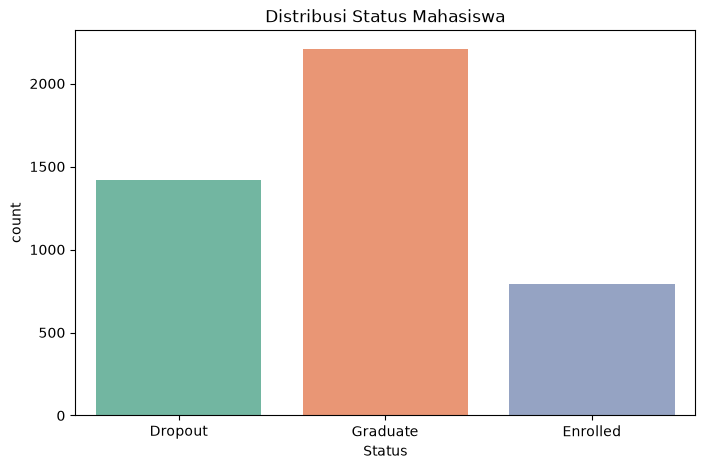

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa')
plt.show()

### EDA Univariate: Distribusi Numerikal (Usia dan Nilai Masuk)

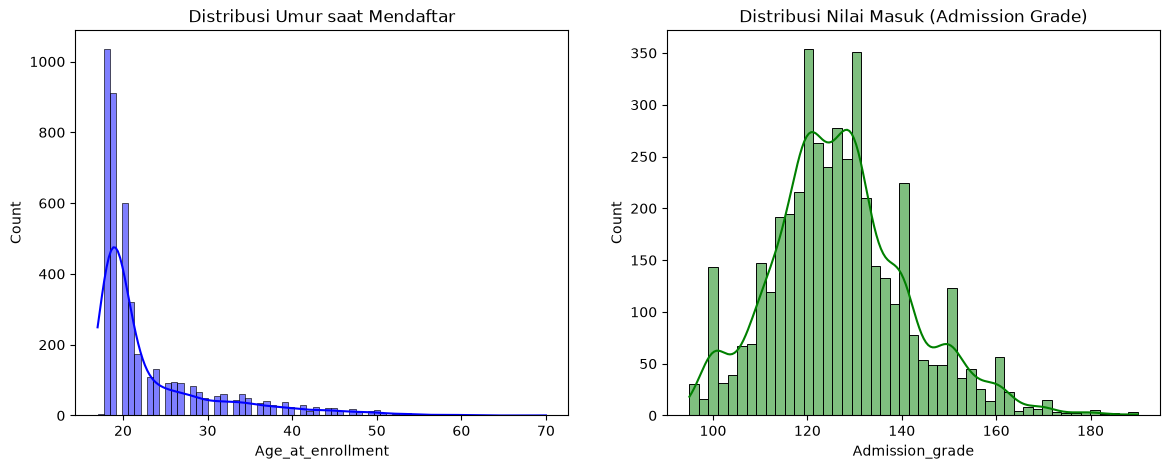

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age_at_enrollment'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Umur saat Mendaftar')

sns.histplot(df['Admission_grade'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribusi Nilai Masuk (Admission Grade)')
plt.show()

**Insight Univariate Numerikal:** Mayoritas mahasiswa mendaftar pada usia sekitar 18-20 tahun. Distribusi nilai masuk (Admission grade) mendekati distribusi normal.

### EDA Multivariate: Hubungan Status dengan Hutang & Tunggakan Biaya Kuliah

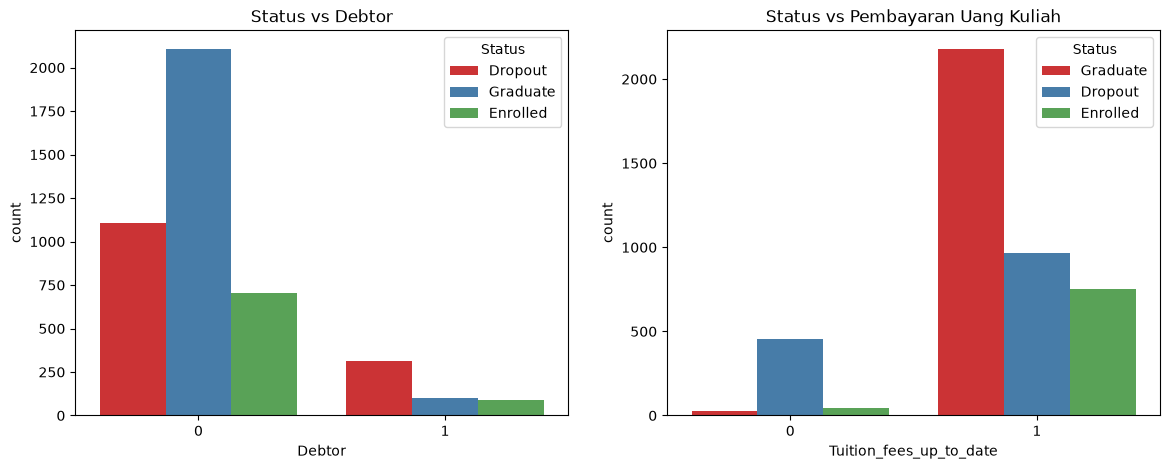

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Debtor', hue='Status', palette='Set1', ax=axes[0])
axes[0].set_title('Status vs Debtor')

sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', palette='Set1', ax=axes[1])
axes[1].set_title('Status vs Pembayaran Uang Kuliah')
plt.show()

**Insight Multivariate Kategorikal:** 
- Mahasiswa yang memiliki hutang (Debtor=1) memiliki tingkat dropout yang sangat tinggi.
- Mahasiswa yang terlambat/tidak update membayar uang kuliah (Tuition_fees_up_to_date=0) didominasi oleh kelas Dropout.

### EDA Multivariate: Performa Akademik Semester 1 dan 2

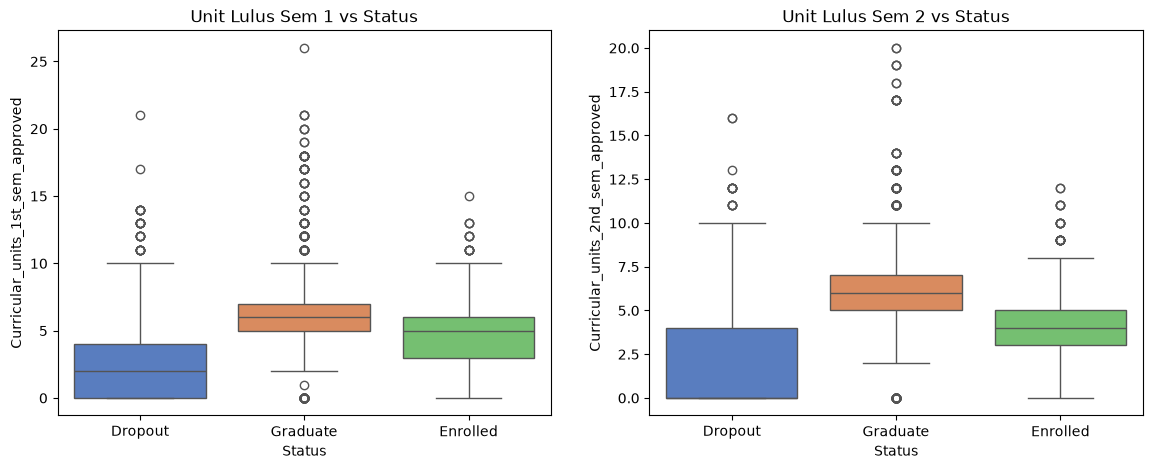

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', palette='muted', ax=axes[0])
axes[0].set_title('Unit Lulus Sem 1 vs Status')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', palette='muted', ax=axes[1])
axes[1].set_title('Unit Lulus Sem 2 vs Status')
plt.show()

**Insight Multivariate Numerikal:** 
- Mahasiswa Dropout gagal meluluskan mata kuliah (Curricular units approved mendekati 0).
- Mahasiswa Graduate stabil meluluskan rata-rata 5-6 mata kuliah tiap semesternya.

## Data Preparation / Preprocessing
Kita akan membuang status 'Enrolled' agar pemodelan fokus pada klasifikasi biner mahasiswa yang lulus (Graduate) dan putus sekolah (Dropout). Lalu kita encode label kategorikal.

In [8]:
# Filter data, hapus 'Enrolled'
df_model = df[df['Status'] != 'Enrolled'].copy()

# Encoding target: Dropout=0, Graduate=1
df_model['Status_Binary'] = df_model['Status'].map({'Dropout': 0, 'Graduate': 1})
df_model.drop(columns=['Status'], inplace=True)

X = df_model.drop(columns=['Status_Binary'])
y = df_model['Status_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling
Kita menggunakan algoritma Random Forest Classifier karena kokoh terhadap outliers dan tidak memerlukan scaling.

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Simpan model
os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/rf_model.joblib')

['model/rf_model.joblib']

## Evaluation
Mengevaluasi performa model pada data testing dan mengekstraksi Feature Importance.

Accuracy: 0.9022
F1-Score: 0.9229

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       277
           1       0.90      0.95      0.92       449

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



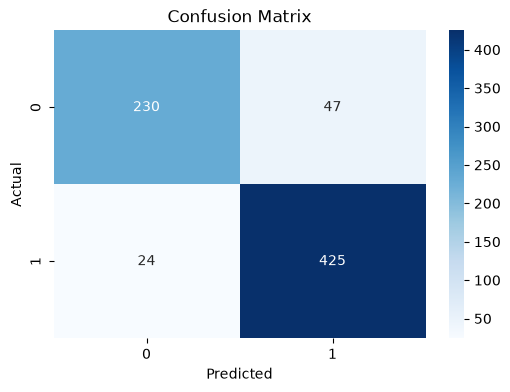

In [10]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Menampilkan Feature Importance

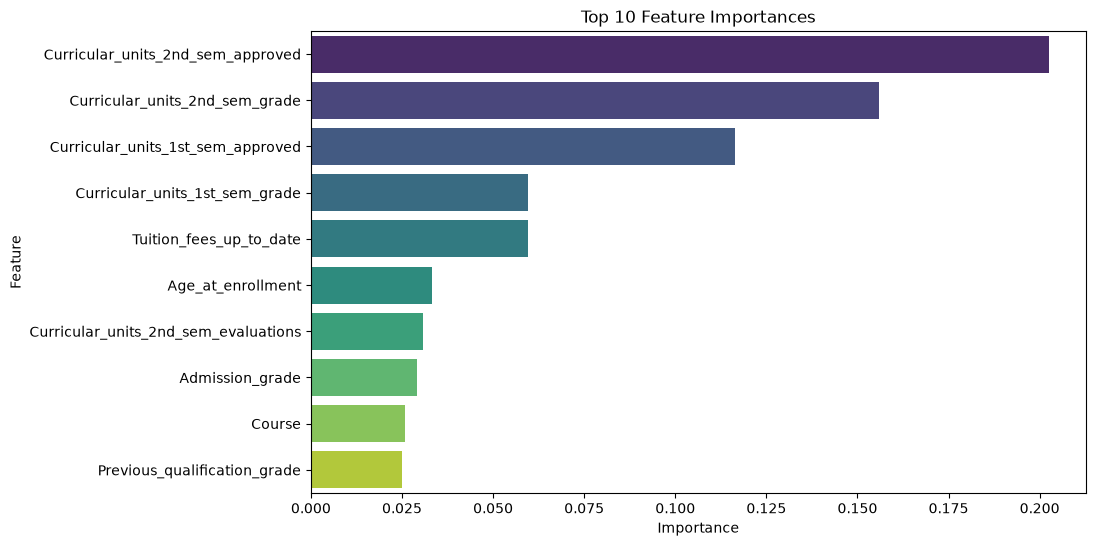

In [11]:
importances = model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances')
plt.show()

**Insight Feature Importance:** Fitur yang paling berpengaruh terhadap model machine learning dalam menentukan Dropout/Graduate adalah **Curricular units 2nd sem approved**, diikuti oleh **Curricular units 1st sem approved**, **Tuition fees up to date**, dan **Age at enrollment**. Ini mengonfirmasi temuan EDA kita.